In [21]:
import pandas as pd
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt

import os, re, glob
import concurrent.futures

import cosmic.utils as cu
from cosmic.panstarrs_dr2 import ColorCalculator

# 2025-10-24: 重新清理的DESI DR1和SDSS DR19样本

# Add PS1DR2 photometry


In [ ]:
path = './data/DESIDR1_xSDSSDR19_xps1dr2loc.fits'  
df_raw = cu.readfile(path)

df = df_raw.copy()

cols_to_rename = {'ra_1': 'ra', 'dec_1': 'dec'}
df = df.rename(columns=cols_to_rename)

cols = ['ra', 'dec', 'z', 'zErr', 
        'DESI_TARGETID', 'DESI_RA', 'DESI_DEC', 'DESI_Z', 'DESI_ZERR',
        'DESI_DELTACHI2', 'DESI_DESI_TARGET', 'DESI_BGS_TARGET', 'DESI_PRIORITY', 
        'SDSS_specobjid', 'SDSS_ra', 'SDSS_dec', 'SDSS_z', 'SDSS_zErr', 'objID']
df = df[cols]

In [ ]:
def process_file(file_path, df_index):
    backg = cu.readfile(file_path).set_index('uid')
    backg = process_backgal(backg)
    common_idx = df_index.intersection(backg.index)
    if common_idx.shape[0] > 0:
        backg = backg[~backg.index.duplicated(keep='first')]
        return backg.loc[common_idx, :]
    return pd.DataFrame()

def process_file(file_path, df_index):
    backg = cu.readfile(file_path).set_index('objID')
    common_idx = df_index.intersection(backg.index)
    if common_idx.shape[0] > 0:
        backg = backg[~backg.index.duplicated(keep='first')]
        return backg.loc[common_idx, :]
    return pd.DataFrame()

def phot_spec_cm(df):
    df = df.set_index('objID')
    file_list = glob.glob(os.path.join('./data/ps1dr2/dered/', '*.fits'))
    
    # 使用字典存储结果，比不断concat更高效
    result_dict = {}
    
    # 预先获取列名
    cols = cu.readfile(file_list[0]).columns
    for col in cols:
        df[col] = np.nan
    
    with concurrent.futures.ProcessPoolExecutor(max_workers=40) as executor:
        futures = {executor.submit(process_file, file, df.index): file for file in file_list}
        
        for n, future in enumerate(concurrent.futures.as_completed(futures), 1):
            try:
                result = future.result()
                if not result.empty:
                    # 使用字典存储结果
                    for idx in result.index:
                        if idx in result_dict:
                            # 如果已经存在，选择保留第一条
                            continue
                        result_dict[idx] = result.loc[idx]
                
                if n % 1000 == 0:
                    print(f"Processed {n}/{len(futures)} files")
            except Exception as e:
                print(f"Error processing file {futures[future]}: {e}")
    
    # 从字典构建DataFrame
    if result_dict:
        combined_df = pd.DataFrame.from_dict(result_dict, orient='index')
        df.update(combined_df)
    
    return df.drop(columns='objID')


df_phot = phot_spec_cm(df)
df_phot = df_phot.reset_index()

cols = ['objID', 'ra', 'dec', 'z', 'zErr', 
        'gPSFMag_dered', 'gPSFMagErr', 'gApMag_dered', 'gApMagErr', 'gKronMag_dered', 'gKronMagErr', 
        'rPSFMag_dered', 'rPSFMagErr', 'rApMag_dered', 'rApMagErr', 'rKronMag_dered', 'rKronMagErr', 
        'iPSFMag_dered', 'iPSFMagErr', 'iApMag_dered', 'iApMagErr', 'iKronMag_dered', 'iKronMagErr', 
        'zPSFMag_dered', 'zPSFMagErr', 'zApMag_dered', 'zApMagErr', 'zKronMag_dered', 'zKronMagErr',
        'yPSFMag_dered', 'yPSFMagErr', 'yApMag_dered', 'yApMagErr', 'yKronMag_dered', 'yKronMagErr',
        'SDSS_specobjid', 'SDSS_z', 'SDSS_zErr',
        'DESI_TARGETID', 'DESI_Z', 'DESI_ZERR', 'DESI_DELTACHI2'
]

df_save = df_phot[cols].copy()

df_save = df_save.apply(pd.to_numeric, errors='coerce')

from astropy.table import Table
path = './data/DESIDR1_xSDSSDR19_xps1dr2phot.fits'
tab = Table.from_pandas(df_save)
tab.write(path, format='fits', overwrite=True)

In [12]:
df_save.columns

Index(['objID', 'ra', 'dec', 'z', 'zErr', 'gPSFMag_dered', 'gPSFMagErr',
       'gApMag_dered', 'gApMagErr', 'gKronMag_dered', 'gKronMagErr',
       'rPSFMag_dered', 'rPSFMagErr', 'rApMag_dered', 'rApMagErr',
       'rKronMag_dered', 'rKronMagErr', 'iPSFMag_dered', 'iPSFMagErr',
       'iApMag_dered', 'iApMagErr', 'iKronMag_dered', 'iKronMagErr',
       'zPSFMag_dered', 'zPSFMagErr', 'zApMag_dered', 'zApMagErr',
       'zKronMag_dered', 'zKronMagErr', 'yPSFMag_dered', 'yPSFMagErr',
       'yApMag_dered', 'yApMagErr', 'yKronMag_dered', 'yKronMagErr',
       'SDSS_specobjid', 'SDSS_z', 'SDSS_zErr', 'DESI_TARGETID', 'DESI_Z',
       'DESI_ZERR', 'DESI_DELTACHI2'],
      dtype='object')

#### data clean

In [ ]:
path = './data/DESIDR1_xSDSSDR19_xps1dr2phot.fits'
df_raw = cu.readfile(path)
df = df_raw.copy()

# 检查所有波段的星等和误差是否为正值
bands = ['g', 'r', 'i', 'z', 'y']
mag_types = ['KronMag_dered', 'PSFMag_dered', 'ApMag_dered',
             'KronMagErr', 'PSFMagErr', 'ApMagErr']

idx = pd.Series(True, index=df.index)
for band in bands:
    for mag_type in mag_types:
        col = f'{band}{mag_type}'
        idx &= df[col] > 0
df = df[idx]
print(f'1: {len(df)}')

# 设置各波段的Kron星等误差阈值
err_thresholds = {'g': 0.2, 'r': 0.1, 'i': 0.05, 'z': 0.1, 'y': 0.2}
idx = pd.Series(True, index=df.index)
for band, threshold in err_thresholds.items():
    idx &= df[f'{band}KronMagErr'] < threshold
df = df[idx]
print(f'2: {len(df)}')

# # 设置各波段的PSF星等误差阈值
# err_thresholds = {'g': 0.1, 'r': 0.04, 'i': 0.03, 'z': 0.04, 'y': 0.1}
# idx = pd.Series(True, index=df.index)
# for band, threshold in err_thresholds.items():
#     idx &= df[f'{band}PSFMagErr'] < threshold
# df = df[idx]
# print('3: ', len(df))

# 设置各波段的Ap星等误差阈值
err_thresholds = {'g': 0.02, 'r': 0.01, 'i': 0.006, 'z': 0.006, 'y': 0.006}
idx = pd.Series(True, index=df.index)
for band, threshold in err_thresholds.items():
    idx &= df[f'{band}ApMagErr'] < threshold
df = df[idx]
print(f'4: {len(df)}')

# 排除可能的点源，点源的PSF与Kron星等比较接近
idx = pd.Series(True, index=df.index)
for band in bands:
    idx &= df[f'{band}PSFMag_dered'] - df[f'{band}KronMag_dered'] > 0.1
df = df[idx]
print(f'5: {len(df)}')

# 红移限制，星等限制
idx = df['zErr'] < 0.001
idx &= df['z'] > 0.01
idx &= df['z'] < 1.2
df = df[idx]
print(f'7: {len(df)}')

# 计算颜色
from cosmic.panstarrs_dr2 import ColorCalculator
colorcalculator = ColorCalculator(df, adjacent_only=True)
df_color = colorcalculator.calculate()

cols = [
    'gPSFMag_dered', 'rPSFMag_dered', 'iPSFMag_dered', 'zPSFMag_dered', 'yPSFMag_dered',
    'gApMag_dered', 'rApMag_dered', 'iApMag_dered', 'zApMag_dered', 'yApMag_dered',
    'gKronMag_dered', 'rKronMag_dered', 'iKronMag_dered', 'zKronMag_dered', 'yKronMag_dered',
    'PSF_gr', 'PSF_ri', 'PSF_iz', 'PSF_zy',
    'Ap_gr', 'Ap_ri', 'Ap_iz', 'Ap_zy',
    'Kron_gr', 'Kron_ri', 'Kron_iz', 'Kron_zy',
]
print(df_color[cols].isna().any(axis=1).sum())

path = './data/DESIDR1_xSDSSDR19_xps1dr2phot_clean.fits'
cu.savefile(df_color, path)

1: 7456902
2: 7195665
4: 7188225
5: 6765669
6: 6764199
7: 6756659


In [2]:
path = './data/DESIDR1_xSDSSDR19_xps1dr2phot_clean.fits'
df_raw = cu.readfile(path)
print(df_raw.shape)

(6756659, 66)


In [3]:
desi_df = df_raw[df_raw['DESI_TARGETID']>0]
print('DESI training sample size:', desi_df.shape)
sdss_df = df_raw[df_raw['SDSS_specobjid']>0]
print('SDSS training sample size:', sdss_df.shape)

DESI training sample size: (5433786, 66)
SDSS training sample size: (1803237, 66)


In [50]:
# 划分训练集、验证集、测试集
path = './data/DESIDR1_xSDSSDR19_xps1dr2phot_clean.fits'
df_raw = cu.readfile(path)
df = df_raw.copy()

# split into train, val, test with 8:1:1 ratio
from sklearn.model_selection import train_test_split
df_trainval, df_test = train_test_split(df, test_size=0.1, random_state=42, shuffle=True)
df_train, df_val = train_test_split(df_trainval, test_size=0.1111, random_state=42, shuffle=True)

print(f"train: {len(df_train)}, val: {len(df_val)}, test: {len(df_test)}")

path = './data/DESIDR1_xSDSSDR19_xps1dr2phot_clean_train.fits'
cu.savefile(df_train, path)
path = './data/DESIDR1_xSDSSDR19_xps1dr2phot_clean_val.fits'
cu.savefile(df_val, path)
path = './data/DESIDR1_xSDSSDR19_xps1dr2phot_clean_test.fits'
cu.savefile(df_test, path)

train: 5405394, val: 675599, test: 675666


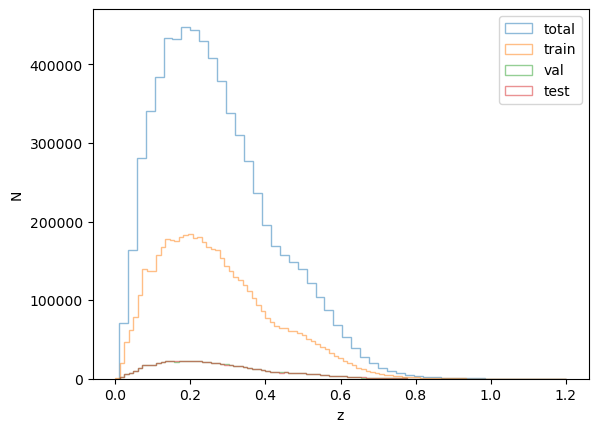

In [96]:
bins = np.linspace(0, 1.2, 100)
plt.hist(df['z'], bins=50, alpha=0.5, histtype='step', label='total')
plt.hist(df_train['z'], bins=bins, alpha=0.5, histtype='step', label='train')
plt.hist(df_val['z'], bins=bins, alpha=0.5, histtype='step', label='val')
plt.hist(df_test['z'], bins=bins, alpha=0.5, histtype='step', label='test')
plt.xlabel('z')
plt.ylabel('N')
plt.legend()
plt.show()

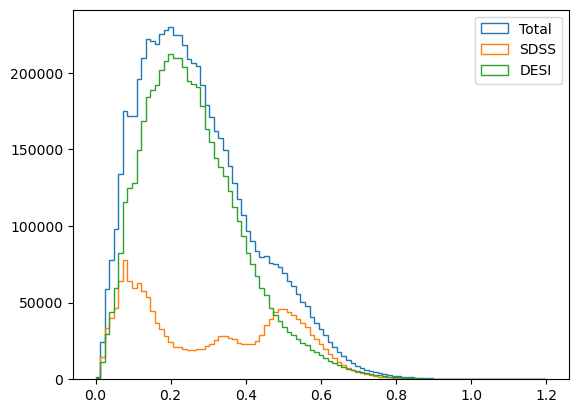

In [59]:
bins = np.linspace(0, 1.2, 100)
plt.hist(df['z'], bins=bins, histtype='step', label='Total');
mask = df['SDSS_z'] > 0 
plt.hist(df[mask]['SDSS_z'], bins=bins, histtype='step', label='SDSS');
mask = df['DESI_Z'] > 0
plt.hist(df[mask]['DESI_Z'], bins=bins, histtype='step', label='DESI');
plt.legend();

In [58]:
df.shape

(6756659, 66)

In [57]:
df.columns

Index(['objID', 'ra', 'dec', 'z', 'zErr', 'gPSFMag_dered', 'gPSFMagErr',
       'gApMag_dered', 'gApMagErr', 'gKronMag_dered', 'gKronMagErr',
       'rPSFMag_dered', 'rPSFMagErr', 'rApMag_dered', 'rApMagErr',
       'rKronMag_dered', 'rKronMagErr', 'iPSFMag_dered', 'iPSFMagErr',
       'iApMag_dered', 'iApMagErr', 'iKronMag_dered', 'iKronMagErr',
       'zPSFMag_dered', 'zPSFMagErr', 'zApMag_dered', 'zApMagErr',
       'zKronMag_dered', 'zKronMagErr', 'yPSFMag_dered', 'yPSFMagErr',
       'yApMag_dered', 'yApMagErr', 'yKronMag_dered', 'yKronMagErr',
       'SDSS_specobjid', 'SDSS_z', 'SDSS_zErr', 'DESI_TARGETID', 'DESI_Z',
       'DESI_ZERR', 'DESI_DELTACHI2', 'PSF_gr', 'PSF_ri', 'PSF_iz', 'PSF_zy',
       'Ap_gr', 'Ap_ri', 'Ap_iz', 'Ap_zy', 'Kron_gr', 'Kron_ri', 'Kron_iz',
       'Kron_zy', 'PSF_gr_Err', 'PSF_ri_Err', 'PSF_iz_Err', 'PSF_zy_Err',
       'Ap_gr_Err', 'Ap_ri_Err', 'Ap_iz_Err', 'Ap_zy_Err', 'Kron_gr_Err',
       'Kron_ri_Err', 'Kron_iz_Err', 'Kron_zy_Err'],
      dtype='o

#### Select subset to train

In [ ]:
# 随机抽取DESI+所有SDSS样本
path = './data/DESIDR1_xSDSSDR19_xps1dr2phot_clean_train.fits'
df_raw = cu.readfile(path)
df = df_raw.copy()

mask = (df['DESI_Z'] > 0) & (df['SDSS_z'].isna())
df_desi = df[mask]
print('DESI sample shape:', df_desi.shape)

mask = (df['DESI_Z'].isna()) & (df['SDSS_z'] > 0)
df_sdss = df[mask]
print('SDSS sample shape:', df_sdss.shape)

# 随机抽取与SDSS等量的DESI样本
_, df_desi_choose = train_test_split(df_desi, test_size=df_sdss.shape[0], 
                                  random_state=2025, shuffle=True)
print('DESI random choosed subsample shape:', df_desi_choose.shape)

df_choose = pd.concat([df_desi_choose, df_sdss], axis=0)
print('Total choosed sample shape:', df_choose.shape)

output_path = './data/DESIDR1_xSDSSDR19_xps1dr2phot_clean_train_SDSS+randomDESI.fits'
cu.savefile(df_choose, output_path)

In [90]:
# 逆频率权重抽样
def balanced_redshift_sampling(df):
    """
    平衡红移抽样：以最高红移区间样本数为基准，其他区间抽取相同数量的样本
    抽多少算多少，不强制达到特定比例
    """
    random_state = 2025
    df = df.copy()
    
    # 获取数据的最大红移值
    z_max = df['z'].max()
    
    # 创建完整的区间边界
    full_bins = [0, 0.1, 0.2, 0.3, 0.4, 0.5] + [z_max]
    
    # 将数据分配到各个红移区间
    df['z_bin'] = pd.cut(df['z'], bins=full_bins, labels=False)
    
    # 计算每个区间的样本数量
    bin_counts = df['z_bin'].value_counts().sort_index()
    print("各红移区间原始样本数:")
    for bin_idx, count in bin_counts.items():
        bin_start = full_bins[bin_idx]
        bin_end = full_bins[bin_idx + 1]
        print(f"  [{bin_start:.2f}, {bin_end:.2f}]: {count} 个样本")
    
    # 以最高红移区间 [bins[-1], z_max] 的样本数为基准
    highest_bin_idx = len(full_bins) - 2  # 最后一个区间的索引
    base_sample_count = bin_counts.get(highest_bin_idx, 0)
    
    print(f"\n以最高红移区间 [{bins[-1]:.2f}, {z_max:.2f}] 为基准，每区抽取 {base_sample_count} 个样本")
    
    # 对每个区间进行抽样
    sampled_dfs = []
    
    for bin_idx in range(len(full_bins) - 1):
        bin_data = df[df['z_bin'] == bin_idx]
        
        if len(bin_data) == 0:
            continue
            
        # 确定该区间要抽取的样本数
        if bin_idx == highest_bin_idx:
            # 最高红移区间：全部抽取
            n_sample = len(bin_data)
            print(f"最高红移区间 [{full_bins[bin_idx]:.2f}, {full_bins[bin_idx+1]:.2f}]: 全部 {n_sample} 个样本都抽取")
        else:
            # 其他区间：抽取基准数量的样本，但不能超过区间总样本数
            n_sample = min(base_sample_count, len(bin_data))
            bin_start = full_bins[bin_idx]
            bin_end = full_bins[bin_idx + 1]
            print(f"区间 [{bin_start:.2f}, {bin_end:.2f}]: 抽取 {n_sample}/{len(bin_data)} 个样本 ({(n_sample/len(bin_data)):.1%})")
        
        bin_sample = bin_data.sample(n=n_sample, random_state=random_state)
        sampled_dfs.append(bin_sample)
    
    # 合并所有抽样结果
    train_df = pd.concat(sampled_dfs, ignore_index=True)
    
    print(f"\n最终训练集: {len(train_df)} 个样本")
    print(f"占总数据比例: {len(train_df)/len(df):.1%}")
    
    return train_df

train_sample = balanced_redshift_sampling(df)

output_path = './data/DESIDR1_xSDSSDR19_xps1dr2phot_clean_train_balanceSample.fits'
cu.savefile(train_sample, output_path)

各红移区间原始样本数:
  [0.00, 0.10]: 625427 个样本
  [0.10, 0.20]: 1411586 个样本
  [0.20, 0.30]: 1385897 个样本
  [0.30, 0.40]: 941472 个样本
  [0.40, 0.50]: 538561 个样本
  [0.50, 1.20]: 502451 个样本

以最高红移区间 [1.20, 1.20] 为基准，每区抽取 502451 个样本
区间 [0.00, 0.10]: 抽取 502451/625427 个样本 (80.3%)
区间 [0.10, 0.20]: 抽取 502451/1411586 个样本 (35.6%)
区间 [0.20, 0.30]: 抽取 502451/1385897 个样本 (36.3%)
区间 [0.30, 0.40]: 抽取 502451/941472 个样本 (53.4%)
区间 [0.40, 0.50]: 抽取 502451/538561 个样本 (93.3%)
最高红移区间 [0.50, 1.20]: 全部 502451 个样本都抽取

最终训练集: 3014706 个样本
占总数据比例: 55.8%


In [111]:
# 分bin，每个bin至少包含minNumPerBin个样本
def bin_minSample(df, minNumPerBin=20000, z_column='z', z_max=1.2, n_bins=100, random_state=42):
    """
    分bin，每个bin至少包含minNumPerBin个样本
    修复groupby警告的版本
    """
    # 创建分箱
    bins = np.linspace(0, z_max, n_bins + 1)
    df = df.copy()
    df['bin_label'] = pd.cut(df[z_column], bins=bins, labels=False, include_lowest=True)
    
    # 定义抽样函数
    def sample_bin(bin_data):
        if len(bin_data) <= minNumPerBin:
            return bin_data
        else:
            return bin_data.sample(minNumPerBin, random_state=random_state)
    
    # 使用include_groups=False排除分组列
    df_sample = df.groupby('bin_label', group_keys=False).apply(sample_bin, include_groups=False)
    df_sample = df_sample.reset_index(drop=True)
    
    print(f"原始数据: {len(df)} 个样本")
    print(f"抽样数据: {len(df_sample)} 个样本")
    print(f"抽样比例: {len(df_sample)/len(df):.2%}")
    
    return df_sample

path = './data/DESIDR1_xSDSSDR19_xps1dr2phot_clean_train.fits'
df_raw = cu.readfile(path)
df = df_raw.copy()

trainval_sample = bin_minSample(df, minNumPerBin=20000)
df_train, df_val = train_test_split(trainval_sample, test_size=0.1111, random_state=42, shuffle=True)
print(f"train: {len(df_train)}, val: {len(df_val)}")

output_path = './data/DESIDR1_xSDSSDR19_xps1dr2phot_clean_train_binMinSample20k_train.fits'
cu.savefile(df_train, output_path)
output_path = './data/DESIDR1_xSDSSDR19_xps1dr2phot_clean_train_binMinSample20k_val.fits'
cu.savefile(df_val, output_path)

原始数据: 5405394 个样本
抽样数据: 1136871 个样本
抽样比例: 21.03%
train: 1010564, val: 126307


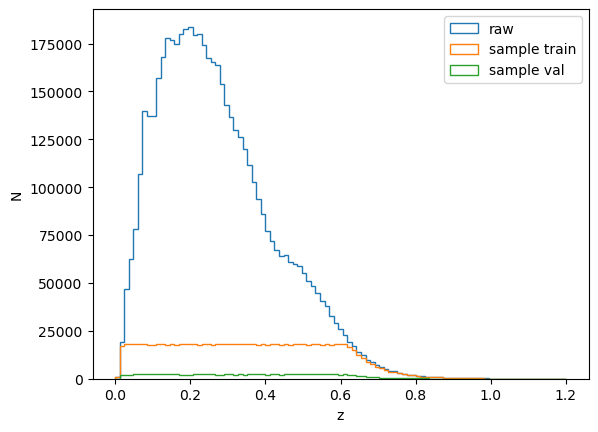

In [112]:
bins = np.linspace(0, 1.2, 100)
plt.hist(df['z'], bins=bins, histtype='step', label='raw');
plt.hist(df_train['z'], bins=bins, histtype='step', label='sample train');
plt.hist(df_val['z'], bins=bins, histtype='step', label='sample val');
plt.xlabel('z')
plt.ylabel('N')
plt.legend()
plt.show()

In [93]:
path = './data/DESIDR1_xSDSSDR19_xps1dr2phot_clean.fits'
df_raw = cu.readfile(path)
df = df_raw.copy()

In [94]:
df_trainval, df_test = train_test_split(df, test_size=0.1, random_state=42, shuffle=True)
df_train, df_val = train_test_split(df_trainval, test_size=0.1111, random_state=42, shuffle=True)

In [73]:
df_desi_choose

,objID,ra,dec,z,zErr,gPSFMag_dered,gPSFMagErr,gApMag_dered,gApMagErr,gKronMag_dered,...,PSF_iz_Err,PSF_zy_Err,Ap_gr_Err,Ap_ri_Err,Ap_iz_Err,Ap_zy_Err,Kron_gr_Err,Kron_ri_Err,Kron_iz_Err,Kron_zy_Err
4407137,131312228157005439,222.815724,19.429087,0.337518,0.000055,21.361873,0.034298,20.280272,0.004712,19.793872,...,0.013324,0.022175,0.005316,0.002893,0.002412,0.002587,0.026261,0.014156,0.014586,0.023484
4530028,105121471445803255,147.144544,-2.397680,0.184258,0.000037,21.259794,0.036295,20.532894,0.005134,20.521993,...,0.016688,0.035946,0.006011,0.003563,0.002930,0.003100,0.040126,0.021983,0.020164,0.039758
178181,135651173522388526,117.352324,23.048304,0.489603,0.000026,22.957530,0.159207,22.548730,0.012694,22.572030,...,0.049086,0.067552,0.013401,0.005830,0.005110,0.004294,0.171610,0.044257,0.049973,0.074890
1303466,111252298059434241,229.805987,2.711436,0.193198,0.000009,20.578078,0.022513,20.171477,0.004060,20.230076,...,0.018791,0.034498,0.005247,0.003668,0.002811,0.003243,0.030863,0.019819,0.023874,0.041367
4589430,133422402663129638,240.266173,21.190857,0.259242,0.000015,21.446526,0.041351,20.871026,0.006479,20.932526,...,0.032752,0.055231,0.007239,0.003859,0.003611,0.003874,0.051868,0.025689,0.036630,0.061518
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4539357,167272652164359745,265.216641,49.399206,0.260969,0.000012,21.028158,0.028537,20.563858,0.005629,20.630457,...,0.025074,0.053443,0.006720,0.004219,0.003821,0.004235,0.037980,0.022508,0.030722,0.059835
627377,189151290507480714,129.050790,67.624966,0.200166,0.000051,19.934233,0.012367,19.521834,0.002287,19.546133,...,0.007243,0.013791,0.002801,0.001777,0.001461,0.001623,0.016471,0.008187,0.009730,0.018350
2259861,128182286560307550,228.655970,16.822529,0.453860,0.000108,21.657314,0.040771,21.301114,0.006381,21.215015,...,0.013219,0.034846,0.007033,0.003281,0.002516,0.002820,0.051051,0.018745,0.018449,0.043072
4329422,101443442596087545,344.259607,-5.460721,0.269824,0.000031,21.426697,0.040590,20.636197,0.004949,20.577798,...,0.018627,0.033456,0.005489,0.002985,0.003026,0.003118,0.039054,0.017842,0.019702,0.032782


In [67]:
mask = (df['DESI_Z'] > 0) & (df['SDSS_z'] > 0)
df[mask].shape

(384199, 66)

# Use only SDSS to train & validate

In [118]:
path = './data/DESIDR1_xSDSSDR19_xps1dr2phot_clean_train.fits'
df_raw = cu.readfile(path)
df = df_raw.copy()

mask = df['SDSS_z'] > 0
df = df[mask]
print(f"SDSS: {len(df)}")

df_train, df_val = train_test_split(df, test_size=0.2, random_state=42, shuffle=True)
print(f"train: {len(df_train)}, val: {len(df_val)}")

output_path = './data/DESIDR1_xSDSSDR19_xps1dr2phot_clean_train_onlySDSS_train.fits'
cu.savefile(df_train, output_path)
output_path = './data/DESIDR1_xSDSSDR19_xps1dr2phot_clean_train_onlySDSS_val.fits'
cu.savefile(df_val, output_path)

SDSS: 1442194
train: 1153755, val: 288439


# Use only DESI DR1 to train & validate

In [122]:
path = './data/DESIDR1_xSDSSDR19_xps1dr2phot_clean_train.fits'
df_raw = cu.readfile(path)
df = df_raw.copy()

mask = df['DESI_Z'] > 0
df = df[mask]
print(f"DESI: {len(df)}")

df_train, df_val = train_test_split(df, test_size=0.2, random_state=42, shuffle=True)
print(f"train: {len(df_train)}, val: {len(df_val)}")

output_path = './data/DESIDR1_xSDSSDR19_xps1dr2phot_clean_train_onlyDESI_train.fits'
cu.savefile(df_train, output_path)
output_path = './data/DESIDR1_xSDSSDR19_xps1dr2phot_clean_train_onlyDESI_val.fits'
cu.savefile(df_val, output_path)

DESI: 4347399
train: 3477919, val: 869480


# DESI DR1 (only BGS+LRG) + SDSS DR19

In [120]:
path = './data/DESIDR1BGSLRG_xSDSSDR19_xps1dr2loc.fits'  
df_raw = cu.readfile(path)

df = df_raw.copy()

cols_to_rename = {'ra_1': 'ra', 'dec_1': 'dec'}
df = df.rename(columns=cols_to_rename)

cols = ['ra', 'dec', 'z', 'zErr', 
        'DESI_TARGETID', 'DESI_RA', 'DESI_DEC', 'DESI_Z', 'DESI_ZERR',
        'DESI_DELTACHI2', 'DESI_DESI_TARGET', 'DESI_BGS_TARGET', 'DESI_PRIORITY', 
        'SDSS_specobjid', 'SDSS_ra', 'SDSS_dec', 'SDSS_z', 'SDSS_zErr', 'objID']
df = df[cols]

In [121]:
def process_file(file_path, df_index):
    backg = cu.readfile(file_path).set_index('uid')
    backg = process_backgal(backg)
    common_idx = df_index.intersection(backg.index)
    if common_idx.shape[0] > 0:
        backg = backg[~backg.index.duplicated(keep='first')]
        return backg.loc[common_idx, :]
    return pd.DataFrame()

def process_file(file_path, df_index):
    backg = cu.readfile(file_path).set_index('objID')
    common_idx = df_index.intersection(backg.index)
    if common_idx.shape[0] > 0:
        backg = backg[~backg.index.duplicated(keep='first')]
        return backg.loc[common_idx, :]
    return pd.DataFrame()

def phot_spec_cm(df):
    df = df.set_index('objID')
    file_list = glob.glob(os.path.join('./data/ps1dr2/dered/', '*.fits'))
    
    # 使用字典存储结果，比不断concat更高效
    result_dict = {}
    
    # 预先获取列名
    cols = cu.readfile(file_list[0]).columns
    for col in cols:
        df[col] = np.nan
    
    with concurrent.futures.ProcessPoolExecutor(max_workers=40) as executor:
        futures = {executor.submit(process_file, file, df.index): file for file in file_list}
        
        for n, future in enumerate(concurrent.futures.as_completed(futures), 1):
            try:
                result = future.result()
                if not result.empty:
                    # 使用字典存储结果
                    for idx in result.index:
                        if idx in result_dict:
                            # 如果已经存在，选择保留第一条
                            continue
                        result_dict[idx] = result.loc[idx]
                
                if n % 1000 == 0:
                    print(f"Processed {n}/{len(futures)} files")
            except Exception as e:
                print(f"Error processing file {futures[future]}: {e}")
    
    # 从字典构建DataFrame
    if result_dict:
        combined_df = pd.DataFrame.from_dict(result_dict, orient='index')
        df.update(combined_df)
    
    return df.drop(columns='objID')


df_phot = phot_spec_cm(df)
df_phot = df_phot.reset_index()

cols = ['objID', 'ra', 'dec', 'z', 'zErr', 
        'gPSFMag_dered', 'gPSFMagErr', 'gApMag_dered', 'gApMagErr', 'gKronMag_dered', 'gKronMagErr', 
        'rPSFMag_dered', 'rPSFMagErr', 'rApMag_dered', 'rApMagErr', 'rKronMag_dered', 'rKronMagErr', 
        'iPSFMag_dered', 'iPSFMagErr', 'iApMag_dered', 'iApMagErr', 'iKronMag_dered', 'iKronMagErr', 
        'zPSFMag_dered', 'zPSFMagErr', 'zApMag_dered', 'zApMagErr', 'zKronMag_dered', 'zKronMagErr',
        'yPSFMag_dered', 'yPSFMagErr', 'yApMag_dered', 'yApMagErr', 'yKronMag_dered', 'yKronMagErr',
        'SDSS_specobjid', 'SDSS_z', 'SDSS_zErr',
        'DESI_TARGETID', 'DESI_Z', 'DESI_ZERR', 'DESI_DELTACHI2'
]

df_save = df_phot[cols].copy()

df_save = df_save.apply(pd.to_numeric, errors='coerce')

from astropy.table import Table
path = './data/DESIDR1BGSLRG_xSDSSDR19_xps1dr2phot.fits'
tab = Table.from_pandas(df_save)
tab.write(path, format='fits', overwrite=True)

Processed 1000/8611 files
Processed 2000/8611 files
Processed 3000/8611 files
Processed 4000/8611 files
Processed 5000/8611 files
Processed 6000/8611 files
Processed 7000/8611 files
Processed 8000/8611 files


In [123]:
path = './data/DESIDR1BGSLRG_xSDSSDR19_xps1dr2phot.fits'
df_raw = cu.readfile(path)
df = df_raw.copy()

# 检查所有波段的星等和误差是否为正值
bands = ['g', 'r', 'i', 'z', 'y']
mag_types = ['KronMag_dered', 'PSFMag_dered', 'ApMag_dered',
             'KronMagErr', 'PSFMagErr', 'ApMagErr']

idx = pd.Series(True, index=df.index)
for band in bands:
    for mag_type in mag_types:
        col = f'{band}{mag_type}'
        idx &= df[col] > 0
df = df[idx]
print(f'1: {len(df)}')

# 设置各波段的Kron星等误差阈值
err_thresholds = {'g': 0.2, 'r': 0.1, 'i': 0.05, 'z': 0.1, 'y': 0.2}
idx = pd.Series(True, index=df.index)
for band, threshold in err_thresholds.items():
    idx &= df[f'{band}KronMagErr'] < threshold
df = df[idx]
print(f'2: {len(df)}')

# # 设置各波段的PSF星等误差阈值
# err_thresholds = {'g': 0.1, 'r': 0.04, 'i': 0.03, 'z': 0.04, 'y': 0.1}
# idx = pd.Series(True, index=df.index)
# for band, threshold in err_thresholds.items():
#     idx &= df[f'{band}PSFMagErr'] < threshold
# df = df[idx]
# print('3: ', len(df))

# 设置各波段的Ap星等误差阈值
err_thresholds = {'g': 0.02, 'r': 0.01, 'i': 0.006, 'z': 0.006, 'y': 0.006}
idx = pd.Series(True, index=df.index)
for band, threshold in err_thresholds.items():
    idx &= df[f'{band}ApMagErr'] < threshold
df = df[idx]
print(f'4: {len(df)}')

# 排除可能的点源，点源的PSF与Kron星等比较接近
idx = pd.Series(True, index=df.index)
for band in bands:
    idx &= df[f'{band}PSFMag_dered'] - df[f'{band}KronMag_dered'] > 0.1
df = df[idx]
print(f'5: {len(df)}')

# 排除DESI与SDSS光谱红移差异大于0.01的星系
overlap_idx = (df['SDSS_z'] > 0) & (df['DESI_Z'] > 0)
overlap_data = df[overlap_idx]
z_diff_mask = abs(overlap_data['DESI_Z'] - overlap_data['SDSS_z']) > 0.005
exclude_idx = overlap_data[z_diff_mask].index
df = df.drop(exclude_idx)
print(f'6: {len(df)}')

# 红移限制，星等限制
idx = df['zErr'] < 0.001
idx &= df['z'] > 0.01
idx &= df['z'] < 1.2
df = df[idx]
print(f'7: {len(df)}')

# 计算颜色
from cosmic.panstarrs_dr2 import ColorCalculator
colorcalculator = ColorCalculator(df, adjacent_only=True)
df_color = colorcalculator.calculate()

cols = [
    'gPSFMag_dered', 'rPSFMag_dered', 'iPSFMag_dered', 'zPSFMag_dered', 'yPSFMag_dered',
    'gApMag_dered', 'rApMag_dered', 'iApMag_dered', 'zApMag_dered', 'yApMag_dered',
    'gKronMag_dered', 'rKronMag_dered', 'iKronMag_dered', 'zKronMag_dered', 'yKronMag_dered',
    'PSF_gr', 'PSF_ri', 'PSF_iz', 'PSF_zy',
    'Ap_gr', 'Ap_ri', 'Ap_iz', 'Ap_zy',
    'Kron_gr', 'Kron_ri', 'Kron_iz', 'Kron_zy',
]
print(df_color[cols].isna().any(axis=1).sum())

path = './data/DESIDR1BGSLRG_xSDSSDR19_xps1dr2phot_clean.fits'
cu.savefile(df_color, path)

1: 7793285
2: 7536862
4: 7528718
5: 7082338
6: 7080733
7: 7072278
0


In [124]:
# 划分训练集、验证集、测试集
path = './data/DESIDR1BGSLRG_xSDSSDR19_xps1dr2phot_clean.fits'
df_raw = cu.readfile(path)
df = df_raw.copy()

# split into train, val, test with 8:1:1 ratio
from sklearn.model_selection import train_test_split
df_train, df_val = train_test_split(df_trainval, test_size=0.2, random_state=42, shuffle=True)

print(f"train: {len(df_train)}, val: {len(df_val)}, test: {len(df_test)}")

path = './data/DESIDR1BGSLRG_xSDSSDR19_xps1dr2phot_clean_train.fits'
cu.savefile(df_train, path)
path = './data/DESIDR1BGSLRG_xSDSSDR19_xps1dr2phot_clean_val.fits'
cu.savefile(df_val, path)


train: 4864794, val: 1216199, test: 675666


# Add unWISE w1 & w2 

In [10]:
paths = {
    'train': './data/xunWISE/DESIDR1_xSDSSDR19_xps1dr2phot_clean_train_xunWISEloc.fits',
    'val': './data/xunWISE/DESIDR1_xSDSSDR19_xps1dr2phot_clean_val_xunWISEloc.fits',
    'test': './data/xunWISE/DESIDR1_xSDSSDR19_xps1dr2phot_clean_test_xunWISEloc.fits',
}
df_train = cu.readfile(paths['train']).set_index('uid')
df_val = cu.readfile(paths['val']).set_index('uid')
df_test = cu.readfile(paths['test']).set_index('uid')

n = 0
for i in range(72):
    unwise_path = f'/home/tiandc/Data/unWISE/clean/unwisedr1_clean_{i:02d}.fits'
    unwise_df = cu.readfile(unwise_path).set_index('uid')
    
    cols = [
        'mag_w1_vg', 'mag_w2_vg',
        'w1_w2_vg', 'flux_w1', 'flux_w2', 'dflux_w1', 'dflux_w2', 'fluxlbs_w1',
        'fluxlbs_w2', 'dfluxlbs_w1', 'dfluxlbs_w2', 'qf_w1', 'qf_w2',
        'rchi2_w1', 'rchi2_w2', 'fracflux_w1', 'fracflux_w2', 'fwhm_w1',
        'fwhm_w2', 'nm_w1', 'nm_w2', 'primary', 'flags_unwise_w1',
        'flags_unwise_w2', 'flags_info_w1', 'flags_info_w2'
    ]
    
    cols_with_prefix = ['unWISE_' + col for col in cols]

    common_idx = df_train.index.intersection(unwise_df.index)
    df_train.loc[common_idx, cols_with_prefix] = unwise_df.loc[common_idx, cols].values

    common_idx = df_val.index.intersection(unwise_df.index)
    df_val.loc[common_idx, cols_with_prefix] = unwise_df.loc[common_idx, cols].values

    common_idx = df_test.index.intersection(unwise_df.index)
    df_test.loc[common_idx, cols_with_prefix] = unwise_df.loc[common_idx, cols].values

    print(f'Finished {i:02d}')
    n += 1
    
# reset index
df_train = df_train.reset_index()
df_val = df_val.reset_index()
df_test = df_test.reset_index()

# rename columns
rename_cols = {
    'ra_2': 'ra',
    'dec_2': 'dec',
    'uid': 'unWISE_uid',
}
df_train = df_train.rename(columns=rename_cols)
df_val = df_val.rename(columns=rename_cols)
df_test = df_test.rename(columns=rename_cols)

# drop columns
drop_cols = ['ra_1', 'dec_1', 'Separation']
df_train = df_train.drop(columns=drop_cols)
df_val = df_val.drop(columns=drop_cols)
df_test = df_test.drop(columns=drop_cols)

def vega_to_ab(mag_vega, band):
    if band == 'w1':
        return mag_vega + 2.699
    elif band == 'w2':
        return mag_vega + 3.339
    else:
        raise ValueError('band must be w1 or w2')

def calc_ab_magerr(flux, flux_err):
    return 1.0857 * (flux_err / flux)

# add w1 w2 columns，转换为AB星等
df_train['mag_w1'] = vega_to_ab(df_train['unWISE_mag_w1_vg'], 'w1')
df_train['mag_w2'] = vega_to_ab(df_train['unWISE_mag_w2_vg'], 'w2')
df_val['mag_w1'] = vega_to_ab(df_val['unWISE_mag_w1_vg'], 'w1')
df_val['mag_w2'] = vega_to_ab(df_val['unWISE_mag_w2_vg'], 'w2')
df_test['mag_w1'] = vega_to_ab(df_test['unWISE_mag_w1_vg'], 'w1')
df_test['mag_w2'] = vega_to_ab(df_test['unWISE_mag_w2_vg'], 'w2')

df_train['mag_w1_err'] = calc_ab_magerr(df_train['unWISE_flux_w1'], df_train['unWISE_dflux_w1'])
df_train['mag_w2_err'] = calc_ab_magerr(df_train['unWISE_flux_w2'], df_train['unWISE_dflux_w2'])
df_val['mag_w1_err'] = calc_ab_magerr(df_val['unWISE_flux_w1'], df_val['unWISE_dflux_w1'])
df_val['mag_w2_err'] = calc_ab_magerr(df_val['unWISE_flux_w2'], df_val['unWISE_dflux_w2'])
df_test['mag_w1_err'] = calc_ab_magerr(df_test['unWISE_flux_w1'], df_test['unWISE_dflux_w1'])
df_test['mag_w2_err'] = calc_ab_magerr(df_test['unWISE_flux_w2'], df_test['unWISE_dflux_w2'])

path_train = './data/xunWISE/DESIDR1_xSDSSDR19_xps1dr2phot_clean_train_xunWISEphot.fits'
path_val = './data/xunWISE/DESIDR1_xSDSSDR19_xps1dr2phot_clean_val_xunWISEphot.fits'
path_test = './data/xunWISE/DESIDR1_xSDSSDR19_xps1dr2phot_clean_test_xunWISEphot.fits'
cu.savefile(df_train, path_train)
cu.savefile(df_val, path_val)
cu.savefile(df_test, path_test)

Finished 00
Finished 01
Finished 02
Finished 03
Finished 04
Finished 05
Finished 06
Finished 07
Finished 08
Finished 09
Finished 10
Finished 11
Finished 12
Finished 13
Finished 14
Finished 15
Finished 16
Finished 17
Finished 18
Finished 19
Finished 20
Finished 21
Finished 22
Finished 23
Finished 24
Finished 25
Finished 26
Finished 27
Finished 28
Finished 29
Finished 30
Finished 31
Finished 32
Finished 33
Finished 34
Finished 35
Finished 36
Finished 37
Finished 38
Finished 39
Finished 40
Finished 41
Finished 42
Finished 43
Finished 44
Finished 45
Finished 46
Finished 47
Finished 48
Finished 49
Finished 50
Finished 51
Finished 52
Finished 53
Finished 54
Finished 55
Finished 56
Finished 57
Finished 58
Finished 59
Finished 60
Finished 61
Finished 62
Finished 63
Finished 64
Finished 65
Finished 66
Finished 67
Finished 68
Finished 69
Finished 70
Finished 71


In [15]:
df_train.columns

Index(['unWISE_uid', 'objID', 'ra', 'dec', 'z', 'zErr', 'gPSFMag_dered',
       'gPSFMagErr', 'gApMag_dered', 'gApMagErr', 'gKronMag_dered',
       'gKronMagErr', 'rPSFMag_dered', 'rPSFMagErr', 'rApMag_dered',
       'rApMagErr', 'rKronMag_dered', 'rKronMagErr', 'iPSFMag_dered',
       'iPSFMagErr', 'iApMag_dered', 'iApMagErr', 'iKronMag_dered',
       'iKronMagErr', 'zPSFMag_dered', 'zPSFMagErr', 'zApMag_dered',
       'zApMagErr', 'zKronMag_dered', 'zKronMagErr', 'yPSFMag_dered',
       'yPSFMagErr', 'yApMag_dered', 'yApMagErr', 'yKronMag_dered',
       'yKronMagErr', 'SDSS_specobjid', 'SDSS_z', 'SDSS_zErr', 'DESI_TARGETID',
       'DESI_Z', 'DESI_ZERR', 'DESI_DELTACHI2', 'PSF_gr', 'PSF_ri', 'PSF_iz',
       'PSF_zy', 'Ap_gr', 'Ap_ri', 'Ap_iz', 'Ap_zy', 'Kron_gr', 'Kron_ri',
       'Kron_iz', 'Kron_zy', 'PSF_gr_Err', 'PSF_ri_Err', 'PSF_iz_Err',
       'PSF_zy_Err', 'Ap_gr_Err', 'Ap_ri_Err', 'Ap_iz_Err', 'Ap_zy_Err',
       'Kron_gr_Err', 'Kron_ri_Err', 'Kron_iz_Err', 'Kron_zy_Err',
 

In [35]:
path_train = './data/xunWISE/DESIDR1_xSDSSDR19_xps1dr2phot_clean_train_xunWISEphot.fits'
path_val = './data/xunWISE/DESIDR1_xSDSSDR19_xps1dr2phot_clean_val_xunWISEphot.fits'
path_test = './data/xunWISE/DESIDR1_xSDSSDR19_xps1dr2phot_clean_test_xunWISEphot.fits'
df_train = cu.readfile(path_train)
print('trainsset: ', df_train.shape)
df_val = cu.readfile(path_val)
print('valset: ', df_val.shape)
df_test = cu.readfile(path_test)
print('testset: ', df_test.shape)

trainsset:  (4152881, 97)
valset:  (519735, 97)
testset:  (519423, 97)


- SDSS only

In [22]:
from sklearn.model_selection import train_test_split
path = './data/xunWISE/DESIDR1_xSDSSDR19_xps1dr2phot_clean_train_xunWISEphot.fits'
df_raw = cu.readfile(path)
df = df_raw.copy()

mask = df['SDSS_z'] > 0
df = df[mask]
print(f"SDSS: {len(df)}")

df_train, df_val = train_test_split(df, test_size=0.2, random_state=42, shuffle=True)
print(f"train: {len(df_train)}, val: {len(df_val)}")

output_path = './data/xunWISE/DESIDR1_xSDSSDR19_xps1dr2phot_clean_train_xunWISEphot_onlySDSS_train.fits'
cu.savefile(df_train, output_path)
output_path = './data/xunWISE/DESIDR1_xSDSSDR19_xps1dr2phot_clean_train_xunWISEphot_onlySDSS_val.fits'
cu.savefile(df_val, output_path)

SDSS: 800717
train: 640573, val: 160144


- DESI only

In [23]:
path = './data/xunWISE/DESIDR1_xSDSSDR19_xps1dr2phot_clean_train_xunWISEphot.fits'
df_raw = cu.readfile(path)
df = df_raw.copy()

mask = df['DESI_Z'] > 0
df = df[mask]
print(f"DESI: {len(df)}")

df_train, df_val = train_test_split(df, test_size=0.2, random_state=42, shuffle=True)
print(f"train: {len(df_train)}, val: {len(df_val)}")

output_path = './data/xunWISE/DESIDR1_xSDSSDR19_xps1dr2phot_clean_train_xunWISEphot_onlyDESI_train.fits'
cu.savefile(df_train, output_path)
output_path = './data/xunWISE/DESIDR1_xSDSSDR19_xps1dr2phot_clean_train_xunWISEphot_onlyDESI_val.fits'
cu.savefile(df_val, output_path)

DESI: 3579689
train: 2863751, val: 715938


In [34]:
df_train[df_train.z>0.1][['ra','dec','z','gKronMag_dered', 'rKronMag_dered', 'iKronMag_dered', 'zKronMag_dered', 'yKronMag_dered',
          'mag_w1', 'mag_w2']].sort_values(by='gKronMag_dered')


,ra,dec,z,gKronMag_dered,rKronMag_dered,iKronMag_dered,zKronMag_dered,yKronMag_dered,mag_w1,mag_w2
1757490,177.353184,-3.925934,0.165490,15.985299,18.408928,18.065401,17.872782,17.739053,17.920675,18.317024
3827726,330.911169,-10.980925,0.515127,16.124814,15.675296,15.520809,15.484226,15.400567,16.706111,17.312783
1095781,141.527972,-8.147535,0.255147,16.194742,19.760824,19.384731,19.156027,19.064003,19.048346,19.274360
1429481,159.308535,40.832992,0.328487,16.220993,19.177256,18.796114,18.570235,18.655751,18.188640,18.412206
646739,105.239576,69.786311,0.103219,16.249477,15.550646,14.944077,14.762521,14.811058,15.648553,16.141854
...,...,...,...,...,...,...,...,...,...,...
1237583,149.497898,1.230726,0.671729,23.550128,21.829837,20.630129,20.405363,20.235748,18.869353,19.058313
1237619,149.718321,1.414242,0.543087,23.571683,21.779940,20.765583,20.494176,20.247061,18.679096,19.239765
1268227,150.629473,1.006305,0.576135,23.594720,21.254083,20.222866,19.949342,19.758900,18.656432,19.323009
1268348,150.302088,1.939183,0.673198,23.669003,21.589230,20.368556,20.187578,19.629297,18.626153,19.184657


In [ ]:
][['ra','dec','z','gKronMag_dered', 'rKronMag_dered', 'iKronMag_dered', 'zKronMag_dered', 'yKronMag_dered',
          'mag_w1', 'mag_w2']].sort_values(by='iKronMag_dered')


In [30]:
df_train.mag_w2.max()

np.float64(21.370259536743163)

In [25]:
df_train.columns

Index(['unWISE_uid', 'objID', 'ra', 'dec', 'z', 'zErr', 'gPSFMag_dered',
       'gPSFMagErr', 'gApMag_dered', 'gApMagErr', 'gKronMag_dered',
       'gKronMagErr', 'rPSFMag_dered', 'rPSFMagErr', 'rApMag_dered',
       'rApMagErr', 'rKronMag_dered', 'rKronMagErr', 'iPSFMag_dered',
       'iPSFMagErr', 'iApMag_dered', 'iApMagErr', 'iKronMag_dered',
       'iKronMagErr', 'zPSFMag_dered', 'zPSFMagErr', 'zApMag_dered',
       'zApMagErr', 'zKronMag_dered', 'zKronMagErr', 'yPSFMag_dered',
       'yPSFMagErr', 'yApMag_dered', 'yApMagErr', 'yKronMag_dered',
       'yKronMagErr', 'SDSS_specobjid', 'SDSS_z', 'SDSS_zErr', 'DESI_TARGETID',
       'DESI_Z', 'DESI_ZERR', 'DESI_DELTACHI2', 'PSF_gr', 'PSF_ri', 'PSF_iz',
       'PSF_zy', 'Ap_gr', 'Ap_ri', 'Ap_iz', 'Ap_zy', 'Kron_gr', 'Kron_ri',
       'Kron_iz', 'Kron_zy', 'PSF_gr_Err', 'PSF_ri_Err', 'PSF_iz_Err',
       'PSF_zy_Err', 'Ap_gr_Err', 'Ap_ri_Err', 'Ap_iz_Err', 'Ap_zy_Err',
       'Kron_gr_Err', 'Kron_ri_Err', 'Kron_iz_Err', 'Kron_zy_Err',
 